In [ ]:
!pip install torch_snippets

In [1]:
!pip install torch datasets

In [9]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch_snippets import Report

In [1]:


# Load the MNIST dataset from Hugging Face
dataset = load_dataset('mnist')

# Access training and testing splits
train_dataset = dataset['train']
test_dataset = dataset['test']

# Convert to PyTorch tensors or NumPy arrays
# For simplicity, let's convert to NumPy arrays first, similar to previous outputs
x_train_hf = np.array([np.array(img).reshape(28, 28) for img in train_dataset['image']])
y_train_hf = np.array(train_dataset['label'], dtype=np.uint8)
x_test_hf = np.array([np.array(img).reshape(28, 28) for img in test_dataset['image']])
y_test_hf = np.array(test_dataset['label'], dtype=np.uint8)

print(f"Shape of x_train_hf: {x_train_hf.shape}")
print(f"Shape of y_train_hf: {y_train_hf.shape}")
print(f"Shape of x_test_hf: {x_test_hf.shape}")
print(f"Shape of y_test_hf: {y_test_hf.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Shape of x_train_hf: (60000, 28, 28)
Shape of y_train_hf: (60000,)
Shape of x_test_hf: (10000, 28, 28)
Shape of y_test_hf: (10000,)


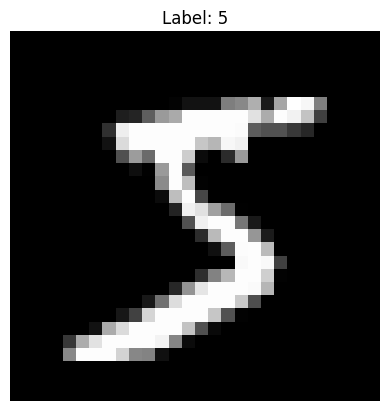

In [2]:

# Display the first image from the training data
plt.imshow(x_train_hf[0], cmap='gray')
plt.title(f"Label: {y_train_hf[0]}")
plt.axis('off') # Hide axes for a cleaner look
plt.show()

In [3]:
x_train_hf[0].shape

(28, 28)

In [4]:


# Convert NumPy arrays to PyTorch tensors
x_train_tensor = torch.tensor(x_train_hf, dtype=torch.float32).unsqueeze(1) / 255.0 # Add channel dimension and normalize
y_train_tensor = torch.tensor(y_train_hf, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_hf, dtype=torch.float32).unsqueeze(1) / 255.0
y_test_tensor = torch.tensor(y_test_hf, dtype=torch.long)

# Create a combined training dataset
train_full_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset_tensor = TensorDataset(x_test_tensor, y_test_tensor)

# Define split ratios for training and validation
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

# Split the dataset into training and validation sets
train_dataset_split, val_dataset = random_split(train_full_dataset, [train_size, val_size])

batch_size = 64

# Create DataLoaders for training, validation, and testing
train_loader = DataLoader(train_dataset_split, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset_tensor, batch_size=batch_size, shuffle=False)

print(f"Shape of x_train_tensor: {x_train_tensor.shape}")
print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
print(f"Training data size: {len(train_dataset_split)}")
print(f"Validation data size: {len(val_dataset)}")

Shape of x_train_tensor: torch.Size([60000, 1, 28, 28])
Shape of y_train_tensor: torch.Size([60000])
Training data size: 48000
Validation data size: 12000


In [5]:
# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 7 * 7, 10) # 32 channels, image size becomes 7x7 after two pooling layers

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7) # Flatten the output for the fully connected layer
        x = self.fc1(x)
        return x

model = SimpleCNN()

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Using device: {device}")
print(model)

Using device: cuda
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=10, bias=True)
)


This code defines a simple Convolutional Neural Network (`SimpleCNN`) with two convolutional layers followed by ReLU activations and max-pooling, and then a final fully connected layer for classification. The model is moved to the GPU if one is available.

In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Here, we define the `CrossEntropyLoss` as the loss function, which is suitable for multi-class classification, and the `Adam` optimizer to update the model's weights during training.

EPOCH: 1.000  train_loss: 0.084  train_acc: 97.494  val_loss: 0.081  val_acc: 97.542  end_of_epoch: 1.000  (2.04s - 28.52s remaining)
Epoch 1/15, Train Loss: 0.0845, Train Acc: 97.49%, Val Loss: 0.0809, Val Acc: 97.54%
EPOCH: 2.000  train_loss: 0.061  train_acc: 98.181  val_loss: 0.062  val_acc: 98.092  end_of_epoch: 1.000  (4.04s - 26.29s remaining)
Epoch 2/15, Train Loss: 0.0611, Train Acc: 98.18%, Val Loss: 0.0619, Val Acc: 98.09%
EPOCH: 3.000  train_loss: 0.051  train_acc: 98.444  val_loss: 0.062  val_acc: 98.158  end_of_epoch: 1.000  (6.05s - 24.20s remaining)
Epoch 3/15, Train Loss: 0.0511, Train Acc: 98.44%, Val Loss: 0.0621, Val Acc: 98.16%
EPOCH: 4.000  train_loss: 0.042  train_acc: 98.688  val_loss: 0.056  val_acc: 98.267  end_of_epoch: 1.000  (9.09s - 24.99s remaining)
Epoch 4/15, Train Loss: 0.0421, Train Acc: 98.69%, Val Loss: 0.0564, Val Acc: 98.27%
EPOCH: 5.000  train_loss: 0.037  train_acc: 98.881  val_loss: 0.049  val_acc: 98.483  end_of_epoch: 1.000  (11.19s - 22.39s 

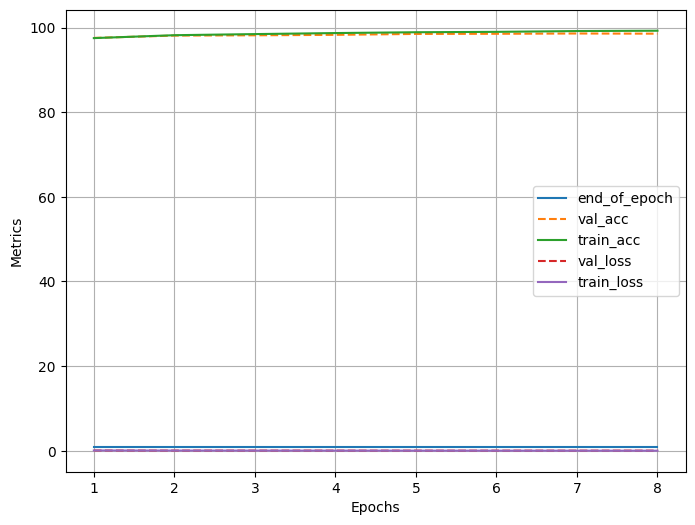

In [8]:


# Training loop
num_epochs = 15 # Increased epochs to allow for early stopping
patience = 3 # Number of epochs to wait for improvement before stopping
min_delta = 0.001 # Minimum change to be considered an improvement

best_val_loss = float('inf')
epochs_no_improve = 0
log = Report(num_epochs) # Initialize Report for logging and plotting

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    avg_train_loss = running_loss / len(train_loader)

    # Validation loop
    model.eval() # Set the model to evaluation mode
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): # Disable gradient calculation during evaluation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    # Record metrics using torch_snippets.Report
    log.record(
        pos=epoch + 1,
        train_loss=avg_train_loss,
        train_acc=train_accuracy,
        val_loss=avg_val_loss,
        val_acc=val_accuracy,
        end_of_epoch=True
    )

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    # Early stopping check
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve == patience:
        print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.')
        break

# Final Evaluation on Test Set
model.eval()
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = 100 * correct_test / total_test
print(f'Finished Training. Final Test Accuracy: {test_accuracy:.2f}%')

# Plotting training history with torch_snippets
log.plot()